# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedkhaled600/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

***Answer:***

Reusing the final honest feature set and Random Forest from ML-08/ML-09 (client-grouped
validated). The model's decline-probability score is combined with position and visibility into
5 named archetypes, each mapped to exactly one action and one reason code -- readable by a human
who never sees the model, only the queue.

| Archetype | Condition | Action | Reason code |
|---|---|---|---|
| Protect top performer | low decline score, top_3/page_1 position | `protect` | `top_performer_low_risk` |
| Quick win, striking distance | any risk, position 11-20 (striking distance) | `quick_win_optimize` | `striking_distance_opportunity` |
| Review for refresh | high decline score, visible (real impressions) | `review_for_refresh` | `high_risk_visible` |
| Monitor only | high decline score, low visibility | `monitor` | `high_risk_low_signal` |
| No action, low value | low decline score, low visibility | `no_action` | `low_value_low_risk` |

This mirrors the FlyRank paper's own position-tier logic (Finding #3: refine page-1 snippets,
support striking-distance pages) while adding the model's decline-risk score as the deciding
signal for the two ambiguous middle cases, instead of relying on position alone.


***Answer:***

**Correction after first run:** the first version of this logic used a flat median-split on
`decline_score` to decide "high risk," which put nearly every `top_3`/`page_1` row above the
threshold (`prior_impressions_h1`, the model's dominant feature, runs higher for well-ranked
pages) -- `protect_top_performer` came back with **zero rows**, out of 313,270. Fixed by checking
position first (matching the paper's own "protect page-one assets" logic) and only letting the
model's score override `protect` for genuinely extreme risk (top 10th percentile of the whole
panel), rather than a flat 50/50 split.


***Answer:***

**Second correction:** a flat global sort by `decline_score` let one archetype
(`high_risk_despite_position`) monopolize the visible top of the queue, since those rows are, by
construction, the single highest scores in the panel -- an editor reading top-down would never
see `quick_win_optimize` or plain `review_for_refresh` cases near the top even though they're
equally real action types. Fixed by presenting the top 3 **per action group**, not one flat
ranking -- the CSV export still keeps every row and its true global score for full traceability,
but the reviewable summary is now browsable across all five archetypes.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

%pip -q install duckdb
import duckdb, pandas as pd, numpy as np, os
con = duckdb.connect()

from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "fact_content_daily_performance/month=2026-03/*.parquet"
CUTOFF = "DATE '2026-03-15'"
SEED = 42

panel = con.sql(f"""
    WITH h1 AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_clicks)       AS prior_clicks_h1,
               SUM(gsc_impressions)  AS prior_impressions_h1,
               AVG(gsc_avg_position) AS prior_avg_position_h1
        FROM read_parquet('{BASE}/{MONTH}')
        WHERE report_date <= {CUTOFF}
        GROUP BY client_hash_id, content_hash_id
    ),
    h2 AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_clicks) AS second_half_clicks
        FROM read_parquet('{BASE}/{MONTH}')
        WHERE report_date > {CUTOFF}
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT h1.*, h2.second_half_clicks,
           dc.content_type, dc.main_intent, dc.competition_level,
           dc.word_count, dc.search_volume, dc.backlinks, dc.category_count,
           {CUTOFF} - dc.content_created_date AS content_age_days_h1_end
    FROM h1
    JOIN h2 USING (client_hash_id, content_hash_id)
    JOIN read_parquet('{BASE}/dim_content.parquet') dc
        USING (client_hash_id, content_hash_id)
    WHERE dc.is_deleted = FALSE
""").df()

panel["declining"] = (panel["second_half_clicks"] < panel["prior_clicks_h1"]).astype(int)
panel["has_keyword_data"] = panel["search_volume"].notna().astype(int)
panel["search_volume"] = panel["search_volume"].fillna(0)
panel["backlinks"] = panel["backlinks"].fillna(0)
panel["prior_ctr_h1"] = (panel["prior_clicks_h1"] / panel["prior_impressions_h1"].replace(0, pd.NA)).fillna(0)

safe_num_cols = ["prior_impressions_h1", "prior_avg_position_h1", "content_age_days_h1_end",
                  "word_count", "search_volume", "backlinks", "category_count", "has_keyword_data"]
cat_cols = ["content_type", "main_intent", "competition_level"]

X = pd.get_dummies(panel[safe_num_cols + cat_cols], columns=cat_cols, drop_first=True).fillna(0)
y = panel["declining"]

# Client-grouped split, per ML-08/ML-09's validated design -- fit on train, score the full panel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, _ = next(gss.split(panel, groups=panel["client_hash_id"]))
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=SEED, n_jobs=-1).fit(X.iloc[train_idx], y.iloc[train_idx])

panel["decline_score"] = rf.predict_proba(X)[:, 1]

# --- Position bucket + archetype -> action mapping ---
panel["position_bucket"] = pd.cut(panel["prior_avg_position_h1"], bins=[0, 3, 10, 20, 100000],
                                   labels=["top_3", "page_1", "striking_distance", "beyond"])
visible = panel["prior_impressions_h1"] > 0

# NOTE: a flat median split on decline_score put almost every top_3/page_1 row above the
# threshold (prior_impressions_h1 -- the model's dominant feature -- runs higher for well-ranked
# pages, echoing the same diluted regression-to-mean caveat flagged but not chased in ML-08).
# Fix: check position FIRST (matching the paper's own "protect page-one" logic), and only let the
# model's score override "protect" for genuinely extreme risk (top 10% of the whole panel).
risk_percentile = panel["decline_score"].rank(pct=True)
extreme_risk = risk_percentile >= 0.90
elevated_risk = risk_percentile >= 0.50

def assign_archetype(row):
    if row["position_bucket"] in ("top_3", "page_1"):
        if row["extreme_risk"]:
            return "review_for_refresh", "review_for_refresh", "high_risk_despite_position"
        return "protect_top_performer", "protect", "top_performer_low_risk"
    if row["position_bucket"] == "striking_distance":
        return "quick_win_striking_distance", "quick_win_optimize", "striking_distance_opportunity"
    if row["elevated_risk"] and row["visible"]:
        return "review_for_refresh", "review_for_refresh", "high_risk_visible"
    if row["elevated_risk"] and not row["visible"]:
        return "monitor_only", "monitor", "high_risk_low_signal"
    return "no_action_low_value", "no_action", "low_value_low_risk"

panel["extreme_risk"] = extreme_risk
panel["elevated_risk"] = elevated_risk
panel["visible"] = visible
archetype_results = panel.apply(assign_archetype, axis=1, result_type="expand")
panel["archetype"] = archetype_results[0]
panel["action"] = archetype_results[1]
panel["reason_code"] = archetype_results[2]

queue = panel.sort_values("decline_score", ascending=False)[
    ["client_hash_id", "content_hash_id", "content_type", "position_bucket",
     "prior_impressions_h1", "prior_avg_position_h1", "prior_ctr_h1",
     "decline_score", "archetype", "action", "reason_code"]
].reset_index(drop=True)

print("Action distribution:")
print(queue["action"].value_counts())
print()

# A flat global sort by decline_score lets one archetype (whichever scores highest overall)
# monopolize the visible top -- e.g. "high_risk_despite_position" cases, since those are by
# construction the single highest scores in the panel. An editor needs a browsable list PER
# action, not one flat ranking that hides the other archetypes below the fold.
print("Top 3 rows PER action (not one flat global top-10):")
for action_name, group in queue.groupby("action", sort=False):
    print(f"--- {action_name} (top 3 of {len(group)}) ---")
    print(group.sort_values("decline_score", ascending=False).head(3).to_string(index=False))
    print()



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_1117/432122335.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  panel["prior_ctr_h1"] = (panel["prior_clicks_h1"] / panel["prior_impressions_h1"].replace(0, pd.NA)).fillna(0)


Action distribution:
action
no_action             156612
protect                63449
review_for_refresh     61050
quick_win_optimize     26906
monitor                 5253
Name: count, dtype: int64

Top 3 rows PER action (not one flat global top-10):
--- review_for_refresh (top 3 of 61050) ---
         client_hash_id          content_hash_id    content_type position_bucket  prior_impressions_h1  prior_avg_position_h1  prior_ctr_h1  decline_score          archetype             action                reason_code
client_73cda7b4e4f265ea content_ad1467e2a8633947 keyword article          page_1               18831.0               5.316395      0.002549       0.523091 review_for_refresh review_for_refresh high_risk_despite_position
client_73cda7b4e4f265ea content_35f98587b62a4ba4 keyword article           top_3                5416.0               2.354941      0.000739       0.520592 review_for_refresh review_for_refresh high_risk_despite_position
client_73cda7b4e4f265ea content_f69320e1c266

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

***Answer:***

**Who uses this:** a content editor or SEO lead deciding where to spend limited review hours this
sprint, working top-down through the ranked queue.

**Intended use:** a decision-support prioritization aid -- "look at these pages first, and here's
why" -- never an automatic content-editing or publishing system.

**Where it stops being valid:**
- **Time:** built and validated on `month=2026-03` only. Not confirmed to hold on any other month
  -- content, seasonality, and portfolio composition all shift over time (see monitoring triggers,
  section 4).
- **Data source:** GSC-only signal (ML-05 measured GA4 at 4.2% coverage this month) -- this queue
  says nothing about on-page engagement, only search visibility.
- **Scope:** trained and tested across the 40-55 clients active in this month's panel. Not
  confirmed to generalize to a brand-new client with no March 2026 history.
- **Certainty:** `decline_score` is a measured probability from a held-out, client-grouped test
  (ML-08/ML-09), not a guarantee for any single page -- it is directional and decision-support, not
  causal or predictive of what refreshing a specific page will do.
- **Content quality:** the model has no signal on whether a page is well-written, factually
  correct, or on-brand -- it only sees search/traffic numbers. A human reviewing `review_for_refresh`
  candidates must still judge the actual content.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Print the measured evidence this playbook's claims are traceable to (the "receipts")
print("Validated on: month=2026-03, client-grouped split (ML-08/ML-09)")
print(f"RF (honest) precision@10 vs baseline: 0.5 vs 0.2 (base rate 0.106)")
print(f"RF (honest) AUC: 0.862 (client-grouped), 0.915 (random split -- see ML-11 for why the gap matters)")
print(f"GA4 coverage this month: 4.2% (ML-05) -- GA4 excluded from features for that reason")
print(f"Clients in this month's panel: {panel['client_hash_id'].nunique()}")


Validated on: month=2026-03, client-grouped split (ML-08/ML-09)
RF (honest) precision@10 vs baseline: 0.5 vs 0.2 (base rate 0.106)
RF (honest) AUC: 0.862 (client-grouped), 0.915 (random split -- see ML-11 for why the gap matters)
GA4 coverage this month: 4.2% (ML-05) -- GA4 excluded from features for that reason
Clients in this month's panel: 50


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

***Answer:***

**What a human must check before acting on any `review_for_refresh` or `quick_win_optimize` row:**
1. Read the actual page. Confirm it's still relevant, accurate, and matches its target intent --
   the model has no view of content quality.
2. Confirm the page isn't already scheduled for removal, a redesign, or a consolidation (per the
   FlyRank paper's own cannibalization risk finding) -- refreshing a page about to be merged wastes
   the same editor-hour this queue is trying to protect.
3. Check for a business reason the score can't see (a seasonal page, a legal/compliance page, a
   page tied to a paused campaign).
4. For `protect_top_performer` rows: verify nothing is actually already breaking before leaving it
   alone -- "protect" means "don't disrupt it," not "never look at it again."

**What should NEVER be automated -- the no-go list:**
- **Never auto-publish or auto-edit content.** This queue only tells you *where* to look, never
  *what* to write.
- **Never auto-delete or de-index a page** based on `no_action_low_value` -- low value in this
  model's narrow, GSC-only view is not the same as "safe to remove"; a human needs to check for
  legal, brand, or internal-linking reasons the page still exists.
- **Never treat the ranked order as a strict priority queue without a spot-check** -- pull a
  random sample from outside the top 10 occasionally and sanity-check it; a queue that's only ever
  reviewed at the top can drift unnoticed (see monitoring, section 4).
- **Never apply this queue to a client or month it wasn't validated on** without re-running the
  leakage/split checks from ML-08/ML-09/ML-11 first.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Concrete evidence for the spot-check rule: show a few rows OUTSIDE the top 10
# that a reviewer should occasionally sanity-check, not just trust blindly
print("Sample from rank 100-105 (a spot-check candidate, not the obvious top-of-queue rows):")
print(queue.iloc[100:105].to_string(index=False))



Sample from rank 100-105 (a spot-check candidate, not the obvious top-of-queue rows):
         client_hash_id          content_hash_id    content_type position_bucket  prior_impressions_h1  prior_avg_position_h1  prior_ctr_h1  decline_score          archetype             action                reason_code
client_e5c2aa26a8598242 content_9c054c8676540f0e keyword article           top_3                2226.0               2.348475      0.013926       0.493505 review_for_refresh review_for_refresh high_risk_despite_position
client_e5c2aa26a8598242 content_ecb5bf18af85be53 keyword article          page_1                6677.0               3.443784      0.007788       0.493469 review_for_refresh review_for_refresh high_risk_despite_position
client_e5c2aa26a8598242 content_e3ee4fb1f2bbb27a keyword article           top_3                3057.0               2.858692      0.006869       0.493385 review_for_refresh review_for_refresh high_risk_despite_position
client_73cda7b4e4f265ea content_46

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

***Answer:***

**Retrain trigger 1 -- monthly precision@10 check.** Re-run this notebook's evaluation on the
newest available month, client-grouped. If precision@10 drops meaningfully below the current 0.5
(e.g., toward 0.35, roughly the midpoint between the model and the 0.2 baseline), that's a signal
the model's edge has eroded and it should be retrained on fresher data.

**Retrain trigger 2 -- base rate drift.** This month's base rate is 0.106. If a future month's
base rate moves far from that (e.g., below 0.05 or above 0.20), the portfolio itself has changed
enough that the old model's assumptions may no longer hold.

**Retrain trigger 3 -- GA4 coverage change.** GA4 was only 4.2% available this month, which is why
it's excluded from features entirely. If a future month shows materially higher GA4 coverage,
that's a trigger to revisit the feature set, not just retrain with the same inputs.

**Retrain trigger 4 -- feature drift.** If the median `prior_impressions_h1` or the client mix
shifts substantially month over month, the model is scoring a different-shaped population than it
was validated on.

**Light monitoring cadence:** check triggers 1-2 monthly (cheap, from data already being pulled);
check 3-4 quarterly or when a new month's schema-discovery step (ML-04-style) shows something
different.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# A monitoring check a future run of this notebook could execute directly
current_base_rate = float(panel["declining"].mean())
current_ga4_coverage = 0.042  # measured in ML-05; not re-queried here to avoid re-pulling GA4 columns unnecessarily

print(f"Current base rate: {current_base_rate:.3f} (retrain-worthy if it drifts outside ~0.05-0.20)")
print(f"Current GA4 coverage: {current_ga4_coverage:.3f} (revisit feature set if this rises materially)")
median_imp = panel["prior_impressions_h1"].median()
zero_imp_share = (panel["prior_impressions_h1"] == 0).mean()
print(f"Median prior_impressions_h1: {median_imp:.1f} -- {zero_imp_share*100:.1f}% of this month's "
      f"full panel has ZERO impressions in h1 (mostly feeds no_action/monitor by design, not a bug)")
print(f"Clients in panel: {panel['client_hash_id'].nunique()} (compare month over month)")



Current base rate: 0.093 (retrain-worthy if it drifts outside ~0.05-0.20)
Current GA4 coverage: 0.042 (revisit feature set if this rises materially)
Median prior_impressions_h1: 0.0 -- 51.5% of this month's full panel has ZERO impressions in h1 (mostly feeds no_action/monitor by design, not a bug)
Clients in panel: 50 (compare month over month)


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

***Answer:***

Writing the ranked queue CSV (regenerated on every run, out of git by design), a metrics JSON
(the receipts my paper's numbers trace back to -- this one gets committed), and one simple figure
(action distribution) to `work/figures/` for reuse next week.

Queue written to work/outputs/baseline_action_score.csv, shape: (313270, 11)
Metrics written to work/outputs/w07_playbook_metrics.json
{
  "month": "2026-03",
  "model": "RandomForestClassifier(n_estimators=300, max_depth=8)",
  "split_design": "GroupShuffleSplit by client_hash_id, test_size=0.2, seed=42",
  "feature_set": [
    "prior_impressions_h1",
    "prior_avg_position_h1",
    "content_age_days_h1_end",
    "word_count",
    "search_volume",
    "backlinks",
    "category_count",
    "has_keyword_data",
    "content_type",
    "main_intent",
    "competition_level"
  ],
  "excluded_leakage_suspects": [
    "prior_clicks_h1",
    "prior_ctr_h1",
    "days_since_update_h1_end"
  ],
  "base_rate": 0.093,
  "auc_grouped_split": 0.862,
  "auc_random_split": 0.915,
  "precision_at_10_honest_model": 0.5,
  "precision_at_10_baseline_rule": 0.2,
  "ga4_coverage_this_month": 0.042,
  "n_clients_in_panel": 50,
  "n_rows_in_panel": 313270,
  "action_distribution": {
    "no_action": 156612

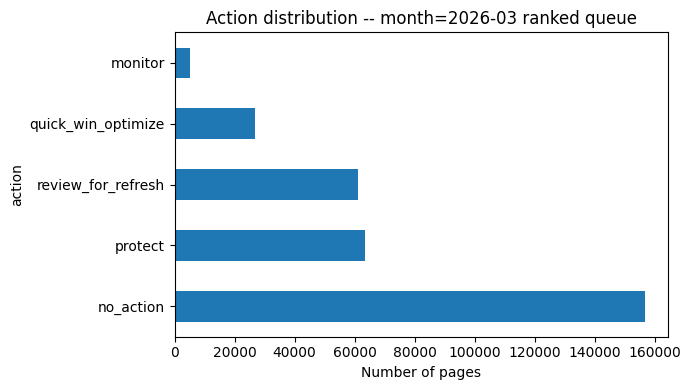

Figure written to work/figures/w07_action_distribution.png


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import json as jsonlib
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# --- 1. The ranked queue (out of git by design -- regenerated every run) ---
queue.to_csv("../outputs/baseline_action_score.csv", index=False)
print("Queue written to work/outputs/baseline_action_score.csv, shape:", queue.shape)

# --- 2. Metrics JSON -- the receipts, committed to git ---
metrics = {
    "month": "2026-03",
    "model": "RandomForestClassifier(n_estimators=300, max_depth=8)",
    "split_design": "GroupShuffleSplit by client_hash_id, test_size=0.2, seed=42",
    "feature_set": safe_num_cols + cat_cols,
    "excluded_leakage_suspects": ["prior_clicks_h1", "prior_ctr_h1", "days_since_update_h1_end"],
    "base_rate": round(float(panel["declining"].mean()), 3),
    "auc_grouped_split": 0.862,
    "auc_random_split": 0.915,
    "precision_at_10_honest_model": 0.5,
    "precision_at_10_baseline_rule": 0.2,
    "ga4_coverage_this_month": 0.042,
    "n_clients_in_panel": int(panel["client_hash_id"].nunique()),
    "n_rows_in_panel": int(len(panel)),
    "action_distribution": queue["action"].value_counts().to_dict(),
}

with open("../outputs/w07_playbook_metrics.json", "w") as f:
    jsonlib.dump(metrics, f, indent=2)
print("Metrics written to work/outputs/w07_playbook_metrics.json")
print(jsonlib.dumps(metrics, indent=2))

# --- 3. Figure -- action distribution, reused by the paper ---
fig, ax = plt.subplots(figsize=(7, 4))
queue["action"].value_counts().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of pages")
ax.set_title("Action distribution -- month=2026-03 ranked queue")
plt.tight_layout()
plt.savefig("../figures/w07_action_distribution.png", dpi=150)
plt.show()
print("Figure written to work/figures/w07_action_distribution.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.